# Setup

In [ ]:
# install libraries
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install seaborn
#!pip install ISLP
#!pip install functools
#!pip install fsklearn
#!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 145.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 35.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 90.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 141.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not w

In [2]:
# import libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF 
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
summarize ,
poly)
from functools import partial
from sklearn.base import clone
from ISLP.models import sklearn_sm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from ISLP.bart import BART
from scipy.stats import shapiro
from scipy import stats


In [3]:
# check working directory
os.getcwd()

'/work/CLOUD_DATA_SCIENCE'

# Data wrangling and dataset creation

In [ ]:
# load data
gini = pd.read_csv('data/gini.csv', index_col=0, skiprows=3) # gini coefficient
gdp = pd.read_csv('data/gdp.csv', index_col=0, skiprows=3) # GDP
inflation = pd.read_csv('data/inflation.csv', index_col=0, skiprows=3) # inflation rate
unemployment = pd.read_csv('data/unemployment.csv', index_col=0, skiprows=3) # unemployment rate
income = pd.read_csv('data/Real wage.csv') # median real earnings
satisfaction = pd.read_csv('data/satisfaction.csv') # satsifaction with personal life and with the US
election_results = pd.read_csv('data/election_results.csv') # electoral outcomes

### Inspect data

In [ ]:
# remove # to see the data
#gini


In [ ]:
#gdp

In [ ]:
#inflation

In [ ]:
#unemployment

In [ ]:
#income

In [ ]:
#satisfaction

In [ ]:
#election_results

### Filter, re-format and rename

#### Gini, GDP, inflation and unemployment

In [ ]:
# filter rows - keep the US only
gini, gdp, inflation, unemployment = [
    df.loc[['United States']]
    for df in [gini, gdp, inflation, unemployment]
]

In [ ]:
# filter columns - drop metadata
gini, gdp, inflation, unemployment = [
    df.drop(columns=["Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])
    for df in [gini, gdp, inflation, unemployment]
]

In [ ]:
# convert from wide to long format
gini, gdp, inflation, unemployment = [
    df.melt(var_name="year", value_name=name)
    for df, name in zip(
        [gini, gdp, inflation, unemployment],
        ["gini", "gdp", "inflation", "unemployment"]
    )
]

In [ ]:
# convert "year" column from string to integer
gini['year'], gdp['year'], inflation['year'], unemployment['year'] = [
    df["year"].astype(int)
    for df in [gini, gdp, inflation, unemployment]
]

#### Income and satisfaction

In [ ]:
# rename column
income = income.rename(columns={"LES1252881600Q": "median_real_wage"})

In [ ]:
# extract year
income['year'] = income['observation_date'].str[:4]
income.head()

,observation_date,median_real_wage,year
0,1979-01-01,335.0,1979
1,1979-04-01,335.0,1979
2,1979-07-01,330.0,1979
3,1979-10-01,326.0,1979
4,1980-01-01,321.0,1980


In [ ]:
# add column only with year
satisfaction['year'] = satisfaction['In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>'].str[-4:]

In [ ]:
# take the mean of multiple observations during a single year
yearly_wage = income.groupby('year')['median_real_wage'].mean()
yearly_pers = satisfaction.groupby('year')['Personal life'].mean() # distribute satisfaction to satsfaction with personal life
yearly_us = satisfaction.groupby('year')['United States'].mean() # distribute satisfaction to satisfaction with the US

In [ ]:
# convert each series into a dataframe
yearly_wage = pd.DataFrame(index= yearly_wage.index, data=yearly_wage.values, columns=['wage'])
yearly_pers = pd.DataFrame(index= yearly_pers.index, data=yearly_pers.values, columns=['pers'])
yearly_us = pd.DataFrame(index= yearly_us.index, data=yearly_us.values, columns=['us'])

In [ ]:
# move year index back into a regular column
yearly_wage.reset_index(inplace=True)
yearly_pers.reset_index(inplace=True)
yearly_us.reset_index(inplace=True)


In [ ]:
# make income and satisfaction integer
yearly_wage['year'] = yearly_wage['year'].astype(int)
yearly_pers['year'] = yearly_pers['year'].astype(int)
yearly_us['year'] = yearly_us['year'].astype(int)

In [ ]:
# check that it worked (remove # to see the data)
#yearly_pers
#yearly_us
#yearly_wage

### Weighted average

In [ ]:
# Create function and define weights for each year of the term (most recent year = highest weight)

def weighted_term_mean(df, value_column, election_years, weights):
    results = []
    for ey in election_years:
        term_years = list(range(ey - 3, ey + 1))  # 4 years leading up to election
        term_data = df[df['year'].isin(term_years)].sort_values('year')
        
        if len(term_data) >= 1:
            w = weights[-len(term_data):]
            w_mean = np.average(term_data[f'{value_column}'].values, weights=w)
        else:
            w_mean = np.nan  # not enough data
            
        results.append({'year': ey, f'{value_column}': w_mean})
    
    return pd.DataFrame(results)

weights = [0.1, 0.2, 0.3, 0.4] # define weights



In [ ]:
# Apply weight function
gini_weighted = weighted_term_mean(gini, 'gini', election_results['year'].tolist(), weights) # gini
gdp_weighted = weighted_term_mean(gdp, 'gdp', election_results['year'].tolist(), weights) # GDP
unemployment_weighted = weighted_term_mean(unemployment, 'unemployment', election_results['year'].tolist(), weights) # unemployment
inflation_weighted = weighted_term_mean(inflation, 'inflation', election_results['year'].tolist(), weights) # inflation
wage_weighted = weighted_term_mean(yearly_wage, 'wage', election_results['year'].tolist(), weights) # income
pers_weighted = weighted_term_mean(yearly_pers, 'pers', election_results['year'].tolist(), weights) # satisfaction with personal life
us_weighted = weighted_term_mean(yearly_us, 'us', election_results['year'].tolist(), weights) # satisfaction with the US


In [ ]:
# check - remove # to see the data
#inflation_weighted

In [ ]:
#pers_weighted

### Merge data

In [ ]:
# merge to single dataframe
prediction_data = pd.merge(election_results, gini_weighted, how='left', on='year') # gini
prediction_data = pd.merge(prediction_data, gdp_weighted, how = 'left', on=['year']) # GDP
prediction_data = pd.merge(prediction_data, unemployment_weighted, how = 'left', on=['year']) # unemployment
prediction_data = pd.merge(prediction_data, inflation_weighted, how = 'left', on=['year']) # inflation
prediction_data = pd.merge(prediction_data, wage_weighted, how = 'left', on=['year']) # income
prediction_data = pd.merge(prediction_data, pers_weighted, how = 'left', on=['year']) # satisaction with personal life
prediction_data = pd.merge(prediction_data, us_weighted, how = 'left', on=['year']) # satisfaction with the US


In [ ]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


### Standardization and reformatting

In [ ]:
# drop missing values - years before 1980
prediction_data = prediction_data.dropna()

In [ ]:
# check
#prediction_data

In [ ]:
# check types
prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party             int64
prospective 1st/2nd term for incumbent party candidate      int64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [ ]:
# make ordinal
enc = OrdinalEncoder(categories=[['1', '2', '3', '4']])  # specify order
prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])

enc = OrdinalEncoder(categories=[['1', '2']])  # specify order
prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2nd term for incumbent party candidate']]) #maybe we should introduce a varibale reflecting the presence of populist candidates, or something regaridn the non-incumbent candidates

C:\Users\carle\AppData\Local\Temp\ipykernel_44548\4048338162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])
C:\Users\carle\AppData\Local\Temp\ipykernel_44548\4048338162.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2

In [ ]:
# check types
prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party           float64
prospective 1st/2nd term for incumbent party candidate    float64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [ ]:
# check
#prediction_data

In [ ]:
# we see that the prediction is in reverse order (most recent year first), we flip that
# make years index
prediction_data = prediction_data.set_index('year')
# make years in ascending order
prediction_data = prediction_data.sort_index()

In [ ]:
# check - remove # to see the data
#prediction_data

Now the data is in the right format, with one value for each variable for each election, no nas, and in the right order, everything has the right data type

# Exploratory analysis

In [ ]:
# standardize for the exploratory analysis and to check for multicollinearity, the unstandardized data will be used later to avoid data leakage
scaled_prediction_data = prediction_data.copy()

cols_to_scale = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']  # standardizing predictors that are not categroical and the outcome

sc = StandardScaler()
scaled_prediction_data[cols_to_scale] = sc.fit_transform(scaled_prediction_data[cols_to_scale])

scaled_prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,-2.291322,-0.393346,0.330846,2.968804,-0.587584,-1.756298,-1.081536
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,-1.238640,1.491179,1.807505,0.523495,-1.186116,-1.303363,0.378828
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,-0.986384,1.145824,0.095436,-0.076432,-0.431381,0.604745,1.286214
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.637107,-0.944981,0.459251,0.158689,-1.098526,-0.395085,0.096567
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,0.279745,0.414211,-0.183346,-0.333541,-1.132102,0.542793,0.351179
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,0.260341,1.492255,-1.270867,-0.446863,-0.308755,1.203610,1.773121
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,0.498043,0.126423,-0.291206,-0.527835,0.221165,0.691477,1.195726
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,0.818214,-1.182503,-0.651312,-0.112423,0.051824,0.026530,-0.885480
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,0.687235,-0.928747,1.938978,-0.643234,0.235763,-1.274452,-1.458566


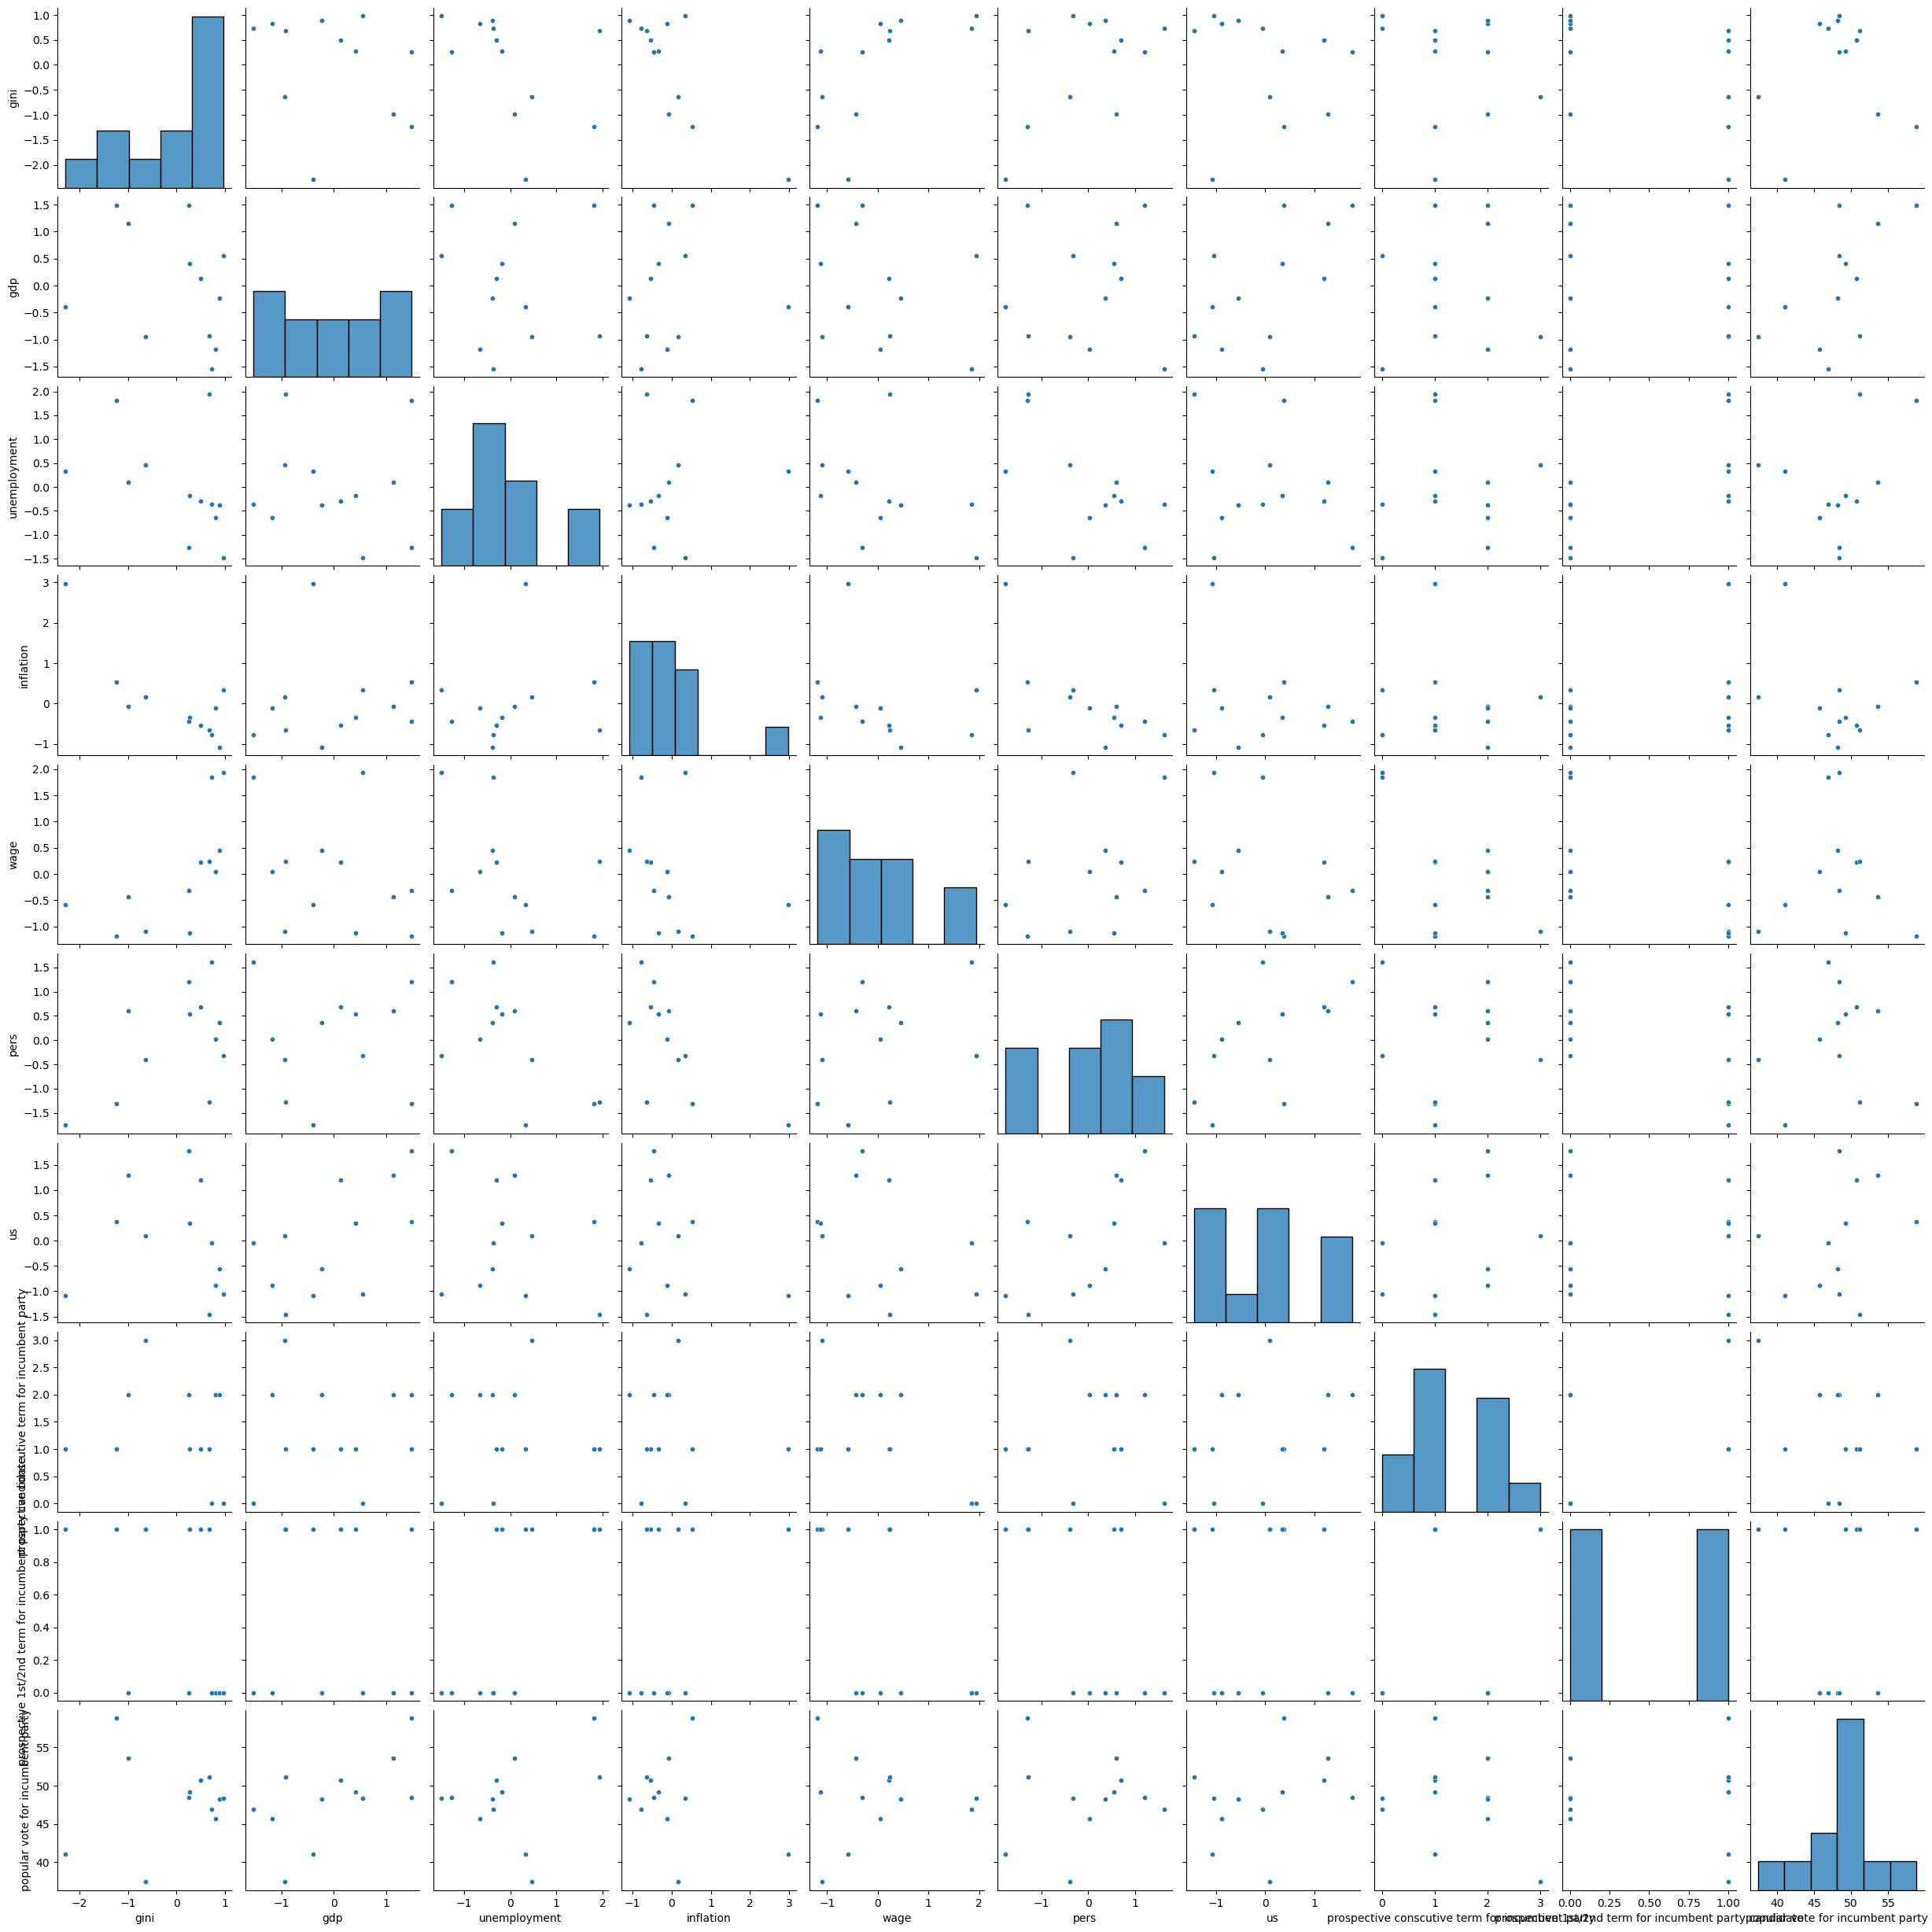

In [ ]:
# plot colinearity
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate', 'popular vote for incumbent party']

sns.pairplot(scaled_prediction_data[cols], plot_kws={'alpha': 1, 's': 20})
plt.show()

We see that there is not that much data - but some patterns of collinearity seem to take shape

In [ ]:
#Define funciton to calculate VIF for each predictor in different sets of predictors (e.g., only economic predictors, only SWB predictors, etc.)
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]
    return vif

In [ ]:
# calculate colinearity with VIF
X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

calculate_vif(X)

,variables,VIF
0,gini,42.379545
1,gdp,4.013833
2,unemployment,22.838278
3,inflation,53.000320
4,wage,3.168965
5,pers,22.538819
6,us,11.596372
7,prospective conscutive term for incumbent party,4.666984
8,prospective 1st/2nd term for incumbent party c...,5.643797


In [ ]:
# calculate colinearity with VIF

X = scaled_prediction_data[['pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


calculate_vif(X)

,variables,VIF
0,pers,2.141974
1,us,1.668037
2,prospective conscutive term for incumbent party,1.761134
3,prospective 1st/2nd term for incumbent party c...,2.187852


In [ ]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


calculate_vif(X)

,variables,VIF
0,gini,8.395828
1,gdp,1.485186
2,unemployment,2.943521
3,inflation,5.976577
4,wage,2.472385
5,prospective conscutive term for incumbent party,2.543081
6,prospective 1st/2nd term for incumbent party c...,3.105601


In [ ]:
# check normality to use pearsons
for col in cols:
    stat, p = shapiro(scaled_prediction_data[col])
    print(f"{col}: p = {p:.3f} {'✅ normal' if p > 0.05 else '❌ not normal'}")

gini: p = 0.033 ❌ not normal
gdp: p = 0.522 ✅ normal
unemployment: p = 0.266 ✅ normal
inflation: p = 0.004 ❌ not normal
wage: p = 0.114 ✅ normal
pers: p = 0.751 ✅ normal
us: p = 0.606 ✅ normal
prospective conscutive term for incumbent party: p = 0.160 ✅ normal
prospective 1st/2nd term for incumbent party candidate: p = 0.000 ❌ not normal
popular vote for incumbent party: p = 0.750 ✅ normal


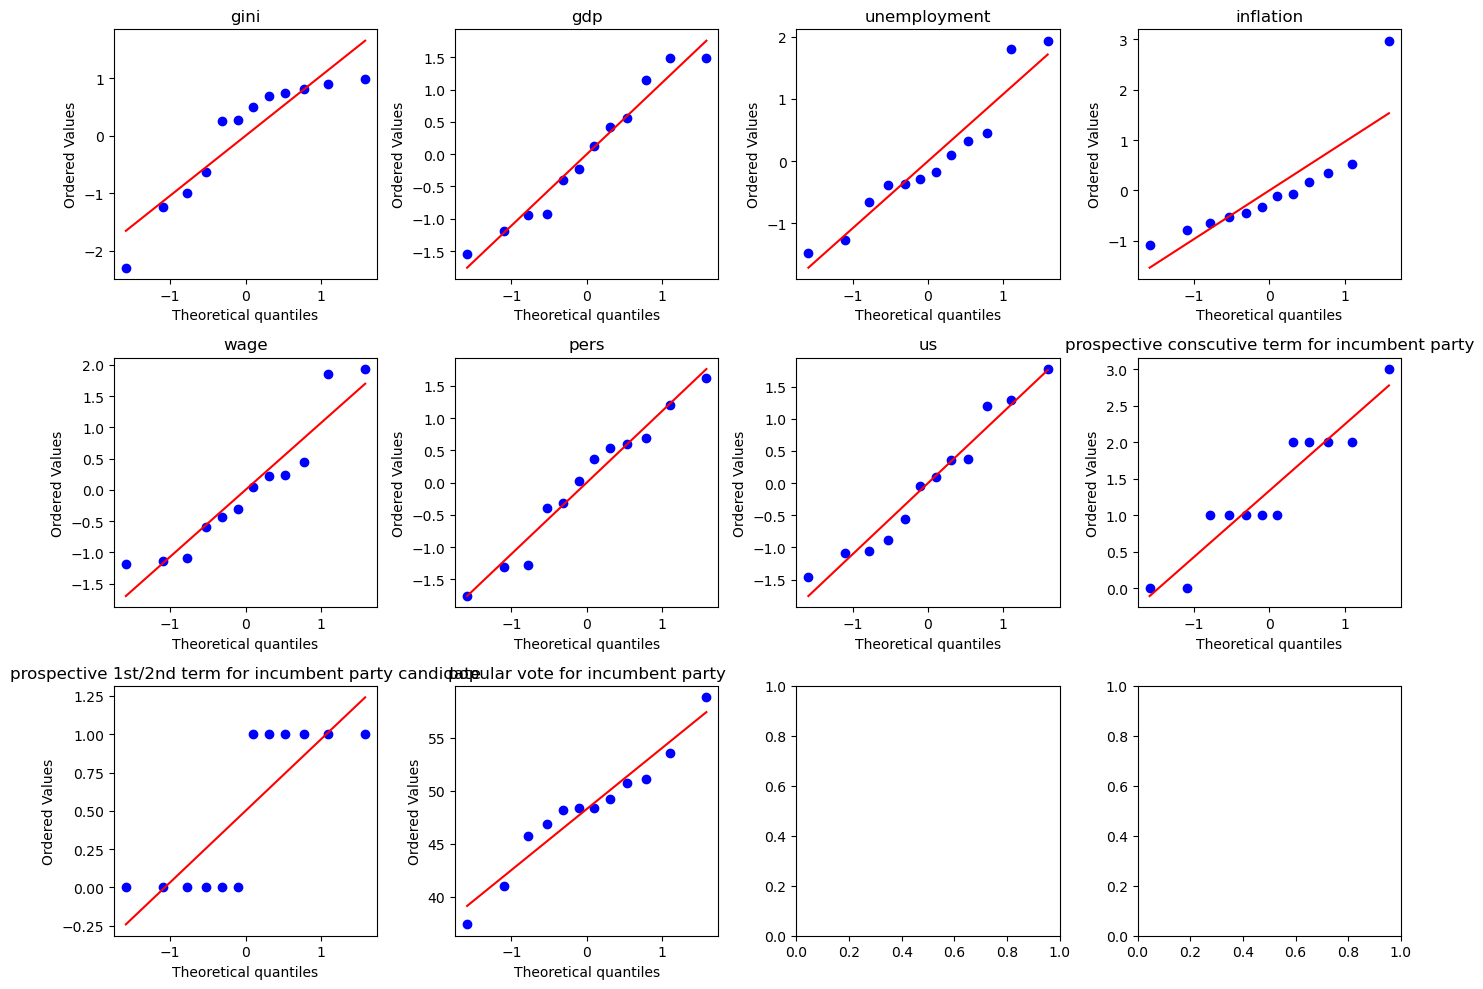

In [ ]:
# check linearity to use pearsons

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats.probplot(scaled_prediction_data[col], plot=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

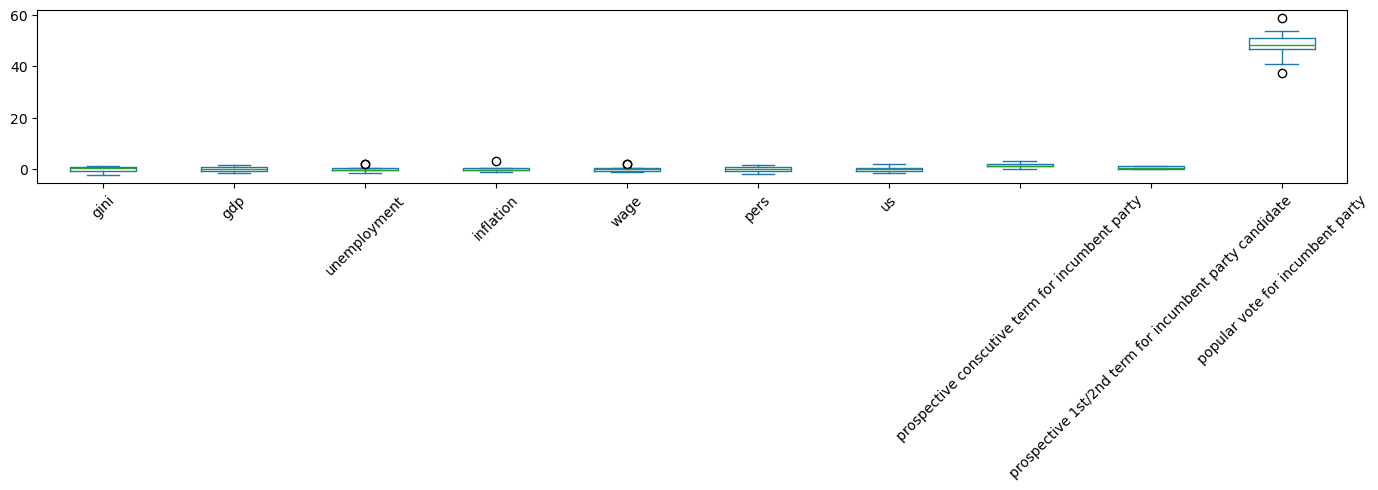

In [ ]:
# check outliers
scaled_prediction_data[cols].plot(kind='box', figsize=(14, 5), rot=45)
plt.tight_layout()
plt.show()

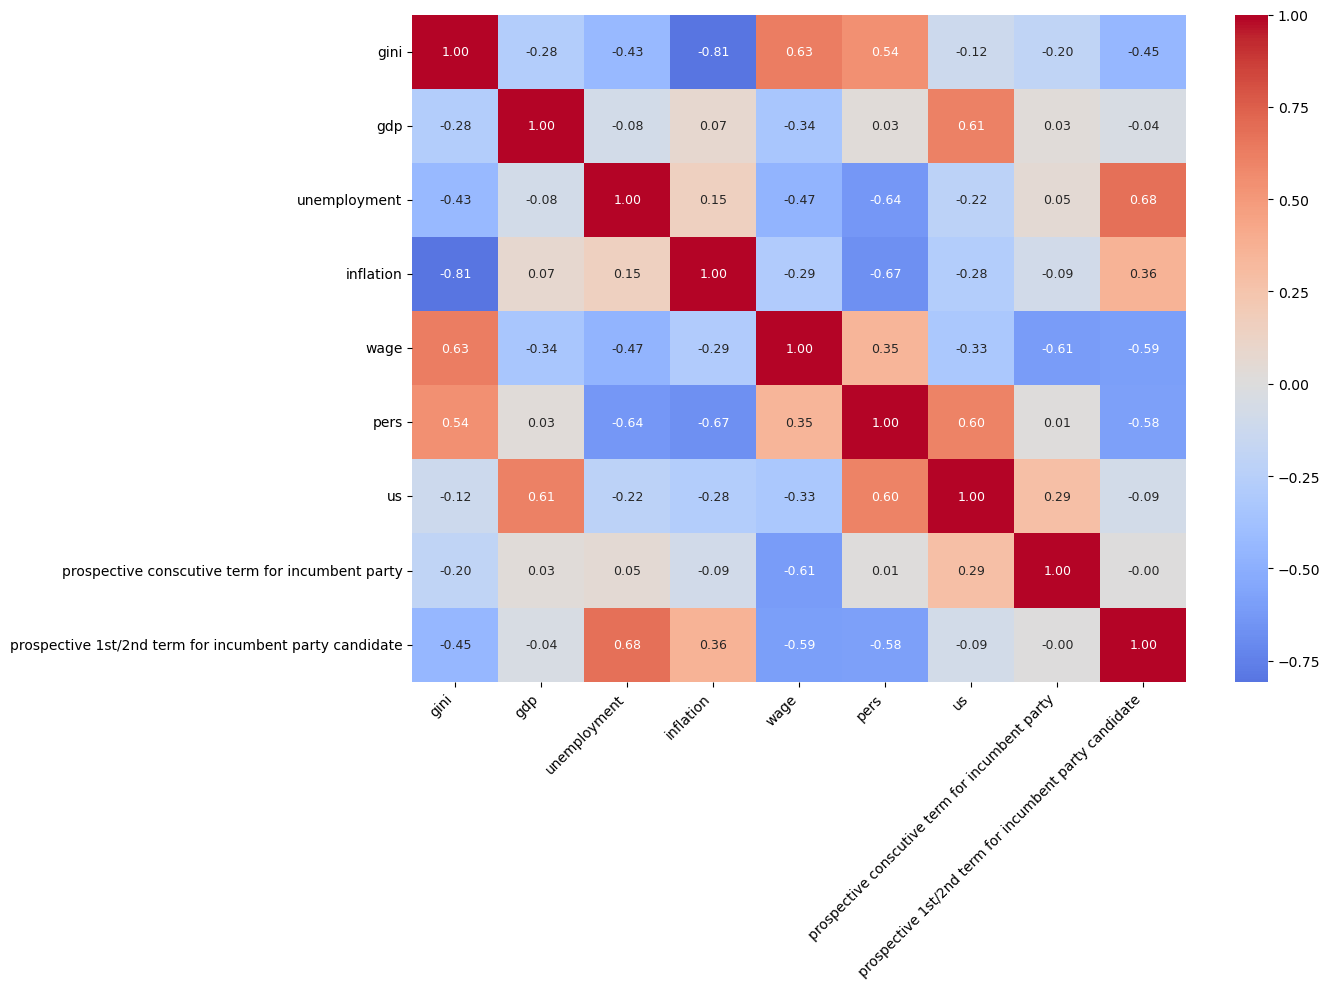

In [ ]:
# correlation matrix (pearson)
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 
        'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

corr = scaled_prediction_data[cols].corr()

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

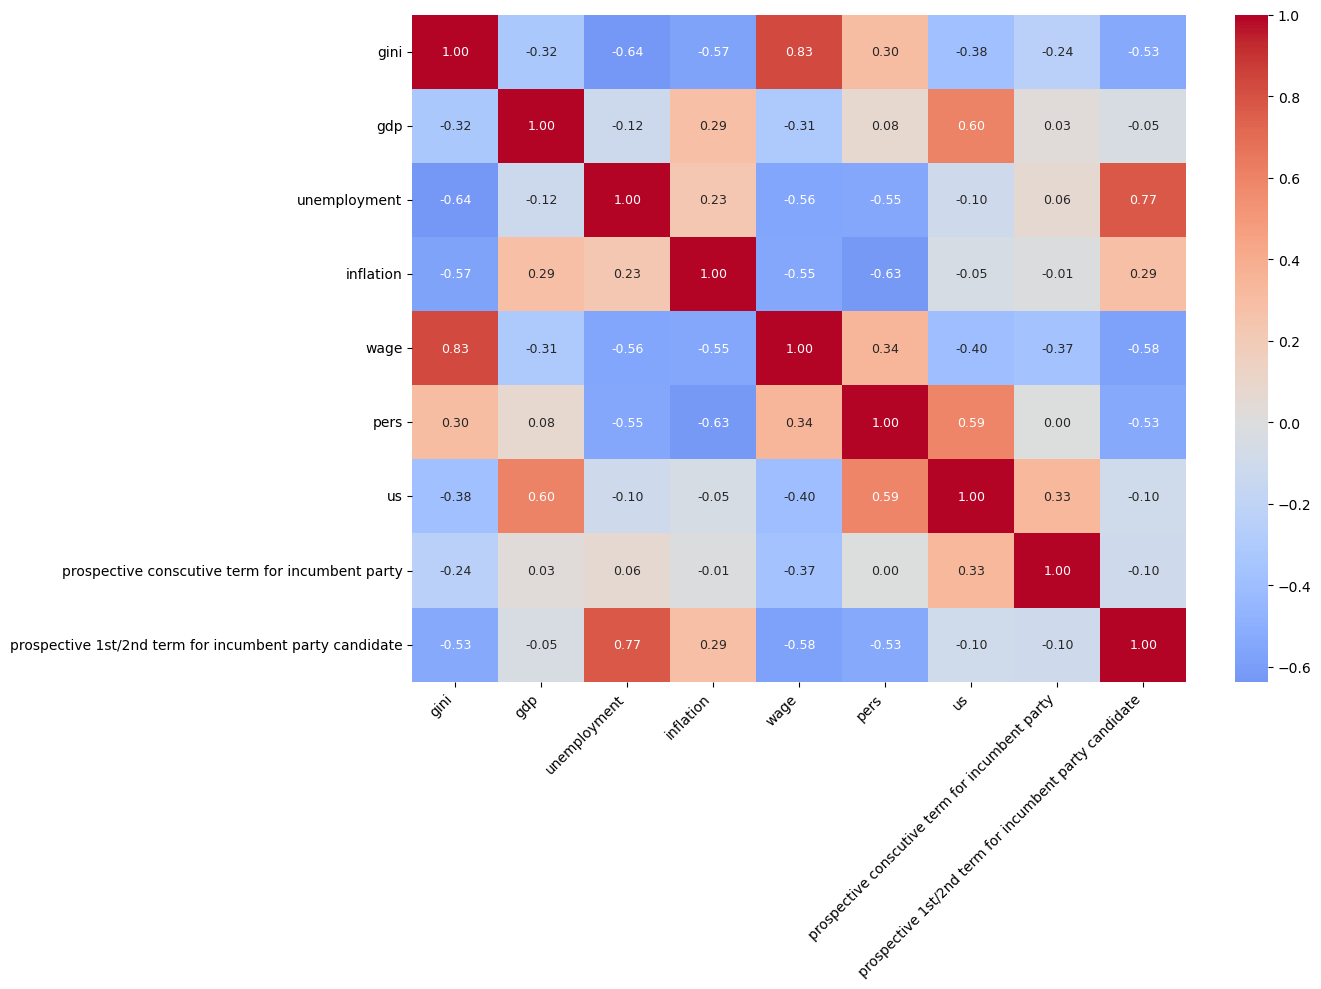

In [ ]:
# spearman correlation matrix
corr_spearman = scaled_prediction_data[cols].corr(method='spearman')
corr_spearman

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

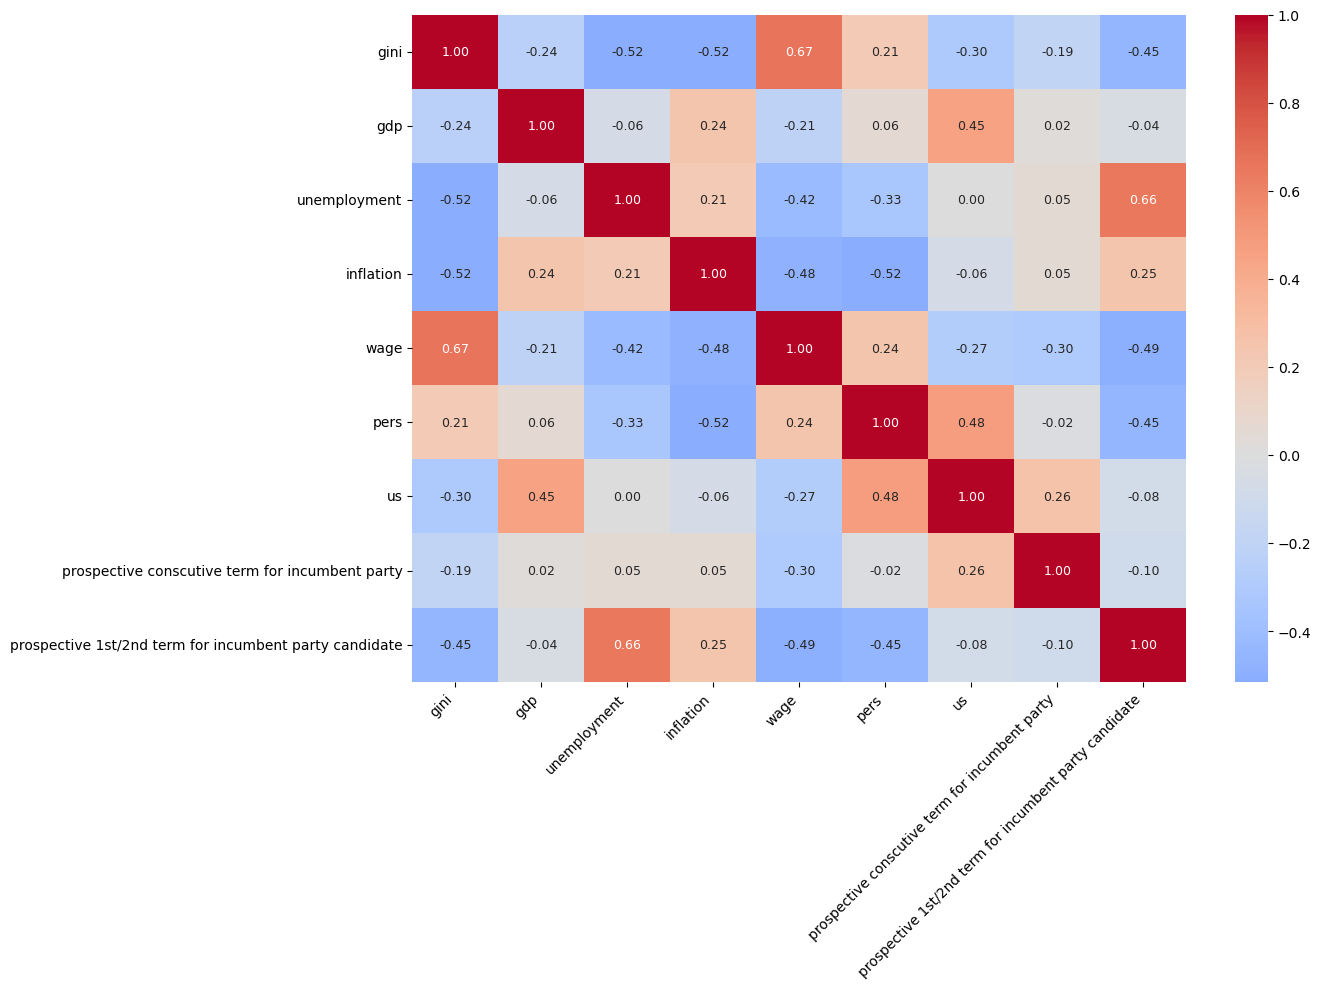

In [ ]:
# kendall correlation matrix
corr_kendall = scaled_prediction_data[cols].corr(method='kendall')
corr_kendall

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_kendall, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

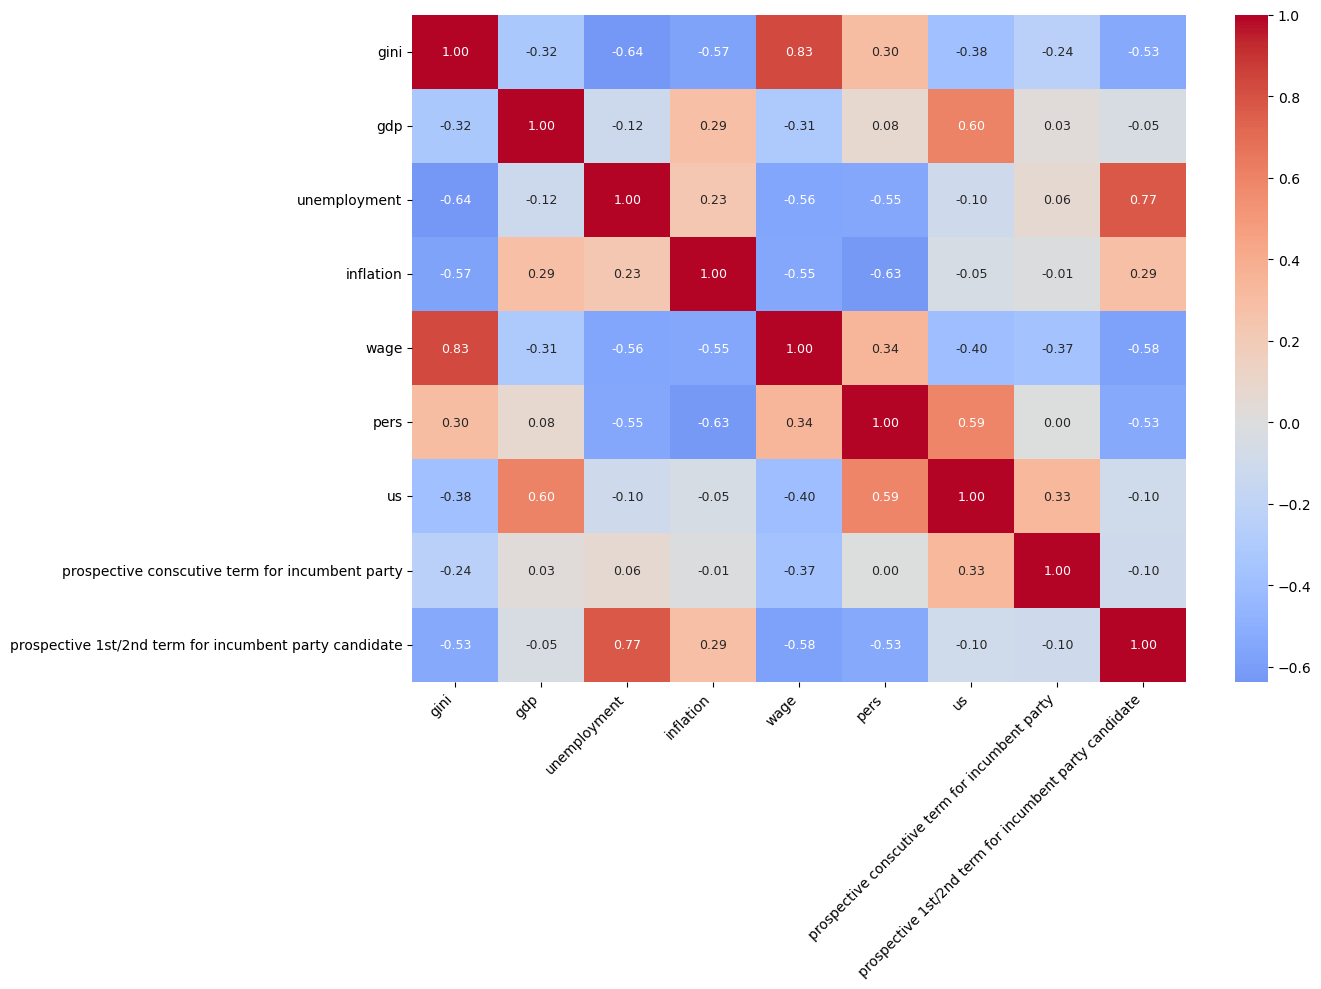

In [ ]:
# save plot
plt.figure(figsize=(14, 10))

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap_spearman.jpg", dpi=150, bbox_inches='tight') 
plt.show()

In [ ]:
## pca
# performing PCA on economic predictors to reduce dimensionality and multicollinearity, and to create a composite economic index
econ_cols = ['gini', 'gdp','unemployment', 'inflation', 'wage']

# Scale first, PCA is sensitive to scale
scaler = StandardScaler()
econ_scaled = scaler.fit_transform(prediction_data[econ_cols])

# Fit PCA
pca = PCA()
pca.fit(econ_scaled)

# Check how many components to keep - how much variance is explained by each component
print(pd.Series(pca.explained_variance_ratio_, 
                index=[f'PC{i+1}' for i in range(len(econ_cols))]))


# Keep 3 components that explain most of the variance
pca = PCA(n_components=3)
econ_pca = pca.fit_transform(econ_scaled)

prediction_data['econ_PC1'] = econ_pca[:, 0]
prediction_data['econ_PC2'] = econ_pca[:, 1]
prediction_data['econ_PC3'] = econ_pca[:, 2]

# Check loadings to attemtp to interpret
loadings = pd.DataFrame(pca.components_.T, 
                         index=econ_cols, 
                         columns=['PC1', 'PC2', 'PC3'])
print(loadings)

PC1    0.502363
PC2    0.215500
PC3    0.190832
PC4    0.074008
PC5    0.017297
dtype: float64
                   PC1       PC2       PC3
gini          0.597454  0.005517 -0.232075
gdp          -0.223707  0.832381 -0.251917
unemployment -0.359798 -0.546687 -0.506378
inflation    -0.462596 -0.051187  0.670270
wage          0.499554 -0.074992  0.420713


## BART

In [40]:
#defining function to do crossvalidationon BART models, including parallelization of the folds
def bart_cv(cols, name, burnin = 200, ndraw = 1000):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    model = BART(random_state =0, burnin = burnin, ndraw = ndraw) #n_tress has default 200

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    tss = TimeSeriesSplit(n_splits=8, test_size=1) #testing on election at a time in sequential order, starting at the 5th

    
    cv_results = cross_validate(pipe, X, Y, cv=tss,  scoring='neg_mean_squared_error', n_jobs=-1) #n_jobs=-1 handles parallelization
    cv_err = np.mean(cv_results['test_score']) 
    cv_df = pd.DataFrame({'method': [name], 'MSE': [-cv_err]}) # saving the crossvalidation MSE to a dataframe

    print(cv_err)
    print(cv_results)
    return(cv_df)


In [41]:
#defining function to predict the last three elections, and save predictions including interval, variable inclusion metric, and the posterior
def bart_pred(cols, name, burnin=200, ndraw=1000, n_elections=3): #500 or 200?
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    X_train, X_test = X.iloc[:-n_elections], X.iloc[-n_elections:]
    Y_train, Y_test = Y.iloc[:-n_elections], Y.iloc[-n_elections:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = BART(random_state=0, burnin=burnin, ndraw=ndraw, num_trees=200)
    
    model.fit(X_train_scaled, Y_train)

    # using staged for both point estimate and intervals
    staged = np.array(list(model.staged_predict(X_test_scaled.astype(np.float32))))
  
    mean_pred = staged.mean(axis=0)
    lower = np.percentile(staged, 2.5, axis=0)
    upper = np.percentile(staged, 97.5, axis=0)

    mse = np.mean((Y_test - mean_pred)**2) # calculate MSE based on the mean prediction

    var_inclusion = pd.Series(model.variable_inclusion_.mean(0), index=X.columns) #getting variable inclusion metrics
    var_df = pd.DataFrame({'predictor': var_inclusion.index, f'{name}_inclusion' : var_inclusion.values}) # saving variable inlcusion metric to a dataframe

    # get staged predictions on training data to check convergence
    staged_train = np.array(list(model.staged_predict(X_train_scaled.astype(np.float32))))

    #plot all predictors traceplots
    fig, axes = plt.subplots(len(cols), 1, figsize=(12, 2*len(cols)))
    for i, col in enumerate(cols):
        axes[i].plot(model.variable_inclusion_[:, i])
        axes[i].set_ylabel(col, fontsize=8)
    plt.tight_layout()
    plt.show()

    #saving the posterior distribution to a dataframe
    distribution_df = pd.DataFrame(staged, columns=Y_test.index.astype(str))
    distribution_df = distribution_df.melt(var_name='year', value_name='prediction')
    distribution_df['method'] = name

    #saving the mean, upper and lowerbounds of 95% interval
    results_df = pd.DataFrame({
        'actual': Y_test.values,
        f'{name}': mean_pred,
        f'{name}_lower': lower,
        f'{name}_upper': upper
    }, index=Y_test.index)

    print(results_df)
    print('MSE:', mse)
    return results_df, var_df, distribution_df

In [42]:
#setting up data frames
all_cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

distribution_df = pd.DataFrame(columns=['year', 'prediction', 'method'])
bart_df = pd.DataFrame()
uncertain_pred_df = pd.DataFrame()
var_df = pd.DataFrame({'predictor': all_cols})

-5.536038145101664
{'fit_time': array([80.60812783, 81.59775186, 80.39227724, 80.8514688 , 80.00858355,
       81.286901  , 81.87686062, 81.57968473]), 'score_time': array([0.63224649, 0.63319683, 0.61918998, 0.62186313, 0.61867547,
       0.68590188, 0.63382125, 0.63315344]), 'test_score': array([ -0.42427687,  -8.08398921,  -3.98339821,  -3.52895099,
       -25.81953113,  -0.28094403,  -1.67570482,  -0.49150989])}


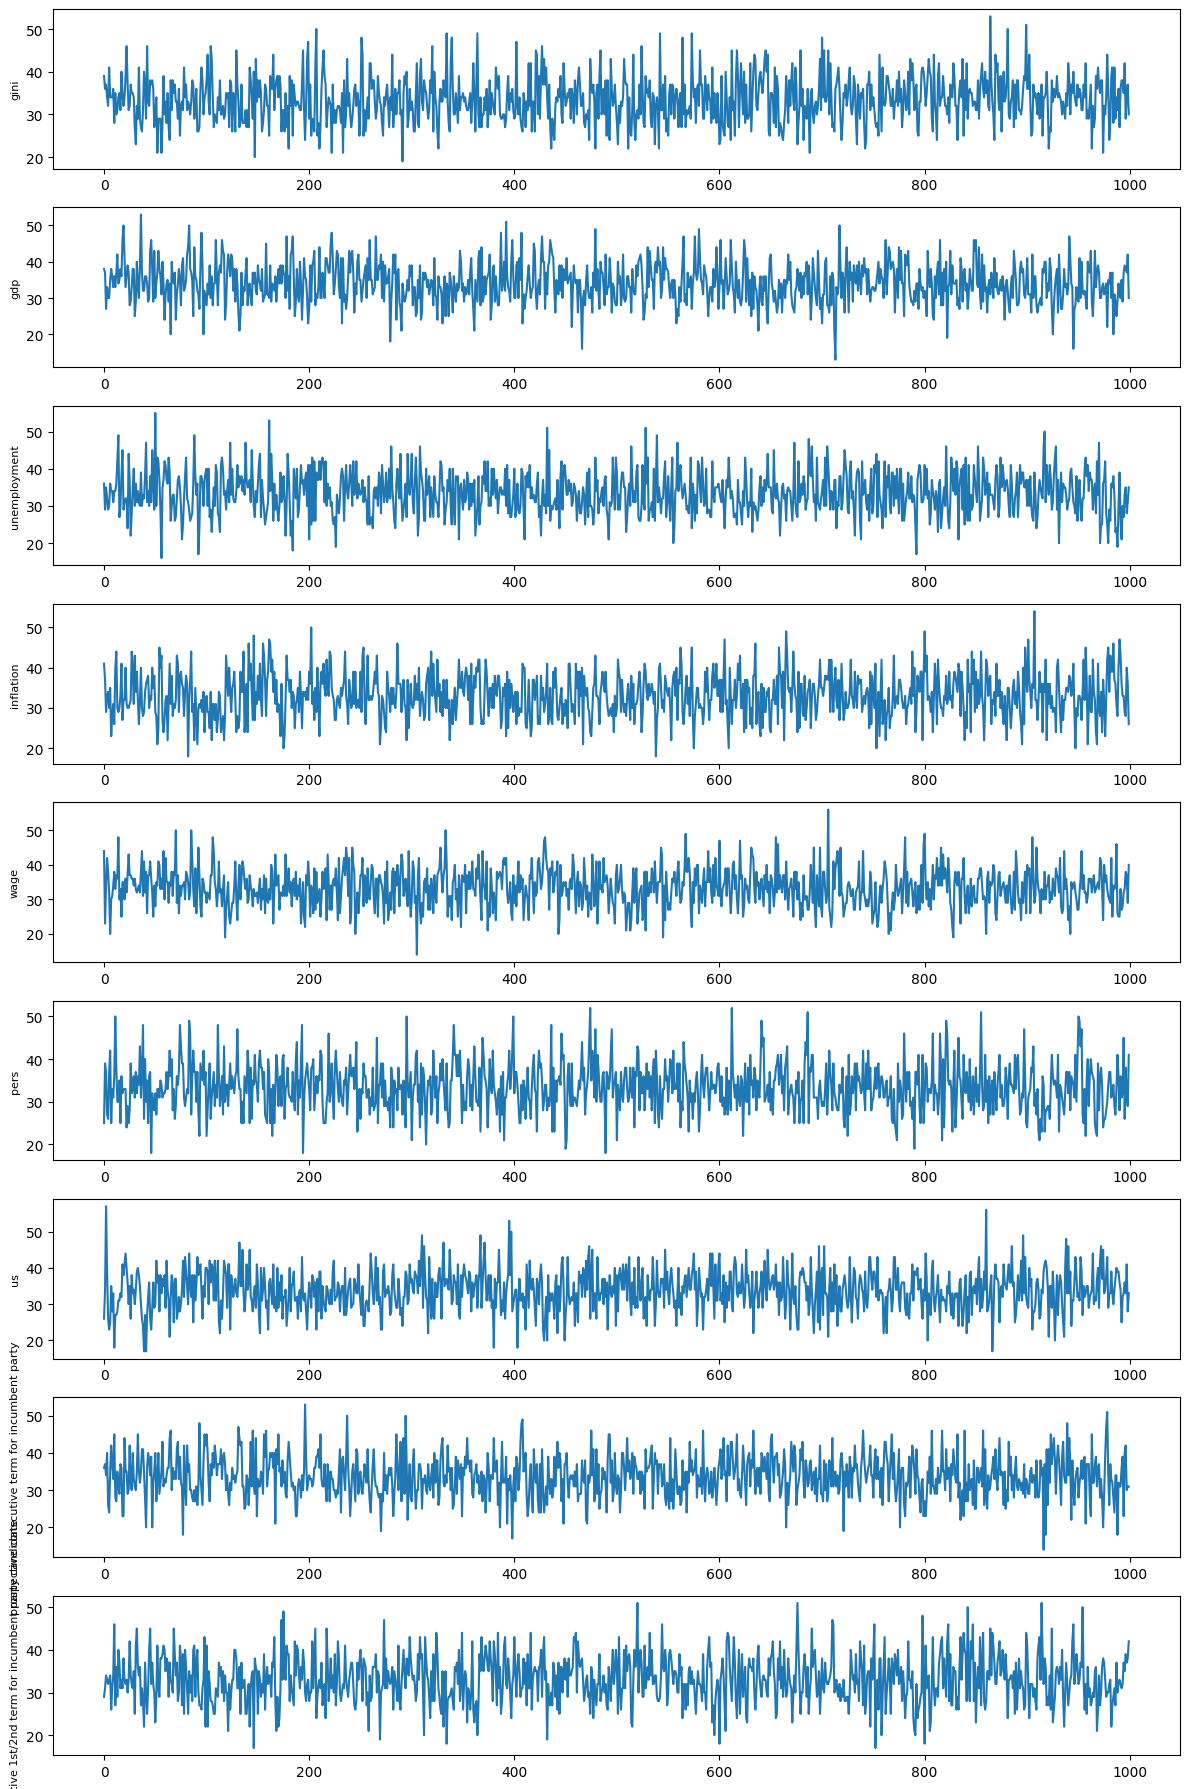

      actual   bart_all  bart_all_lower  bart_all_upper
year                                                   
2016   48.20  47.406033       46.911056       47.587911
2020   46.86  48.042928       47.316690       48.256045
2024   48.34  48.305381       47.740520       48.517232
MSE: 0.676966322278342


/tmp/ipykernel_487/3399473834.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  distribution_df = pd.concat([distribution_df, distribution_df_temp])


In [ ]:
# CV bart all predictors
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_all'

bart_df = bart_cv(cols, name)

#handling the dataframes
uncertain_pred_df, var_df_temp, distribution_df_temp = bart_pred(cols, name)
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])
distribution_df = pd.concat([distribution_df, distribution_df_temp])

In [44]:
distribution_df

,year,prediction,method
0,2016,44.456848,bart_all
1,2016,44.414598,bart_all
2,2016,45.806094,bart_all
3,2016,46.993936,bart_all
4,2016,47.895825,bart_all
...,...,...,...
2995,2024,48.491402,bart_all
2996,2024,48.489038,bart_all
2997,2024,48.491809,bart_all
2998,2024,48.489218,bart_all


-7.973050229003917
{'fit_time': array([76.33638692, 80.91953659, 79.5563097 , 79.55329776, 81.45642996,
       79.88297701, 79.26003575, 81.46550798]), 'score_time': array([0.61791229, 0.6573298 , 0.68813181, 0.65193129, 0.66210628,
       0.65291047, 0.63116837, 0.6249876 ]), 'test_score': array([-8.09509298e-01, -9.83209013e-01, -2.99926827e+00, -1.30458018e-03,
       -4.63771924e+01, -3.76578377e-01, -1.71294228e+00, -1.05243977e+01])}


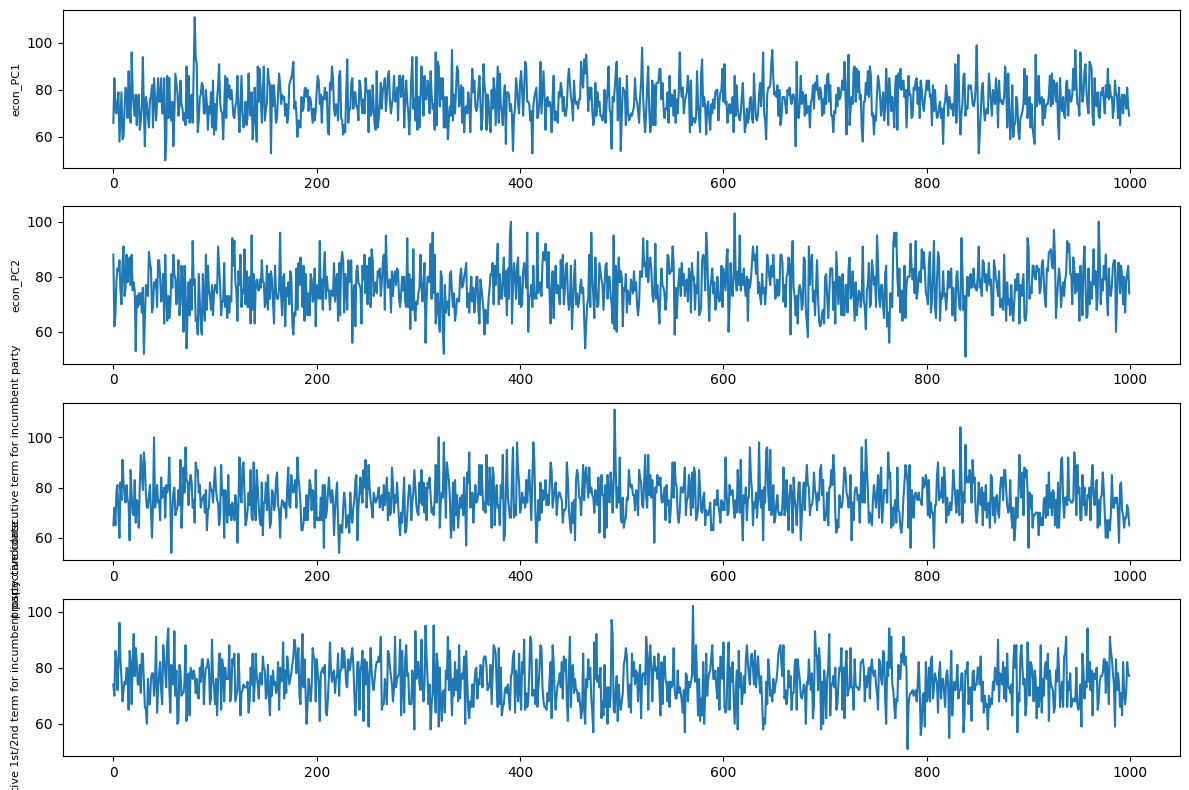

      actual  bart_PC2_econ  bart_PC2_econ_lower  bart_PC2_econ_upper
year                                                                 
2016   48.20      47.230462            47.087446            47.585254
2020   46.86      47.787625            47.380574            47.969653
2024   48.34      51.760233            51.544561            52.425460
MSE: 4.499495301531821


In [ ]:
#bart economic
cols = ['econ_PC1', 'econ_PC2',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_PC2_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp, distribution_df_temp = bart_pred(cols, name)
uncertain_pred_df = pd.merge(uncertain_pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])
distribution_df = pd.concat([distribution_df, distribution_df_temp])

-4.140850828920428
{'fit_time': array([76.67637038, 78.82000017, 80.78359437, 80.32658672, 80.14982462,
       80.69339371, 80.21777558, 81.37123132]), 'score_time': array([0.58758569, 0.63309383, 0.63343978, 0.66986179, 0.63441181,
       0.62029505, 0.64151096, 0.65010595]), 'test_score': array([-6.181685  , -0.53800231, -9.74033615, -2.40946391, -5.10325981,
       -5.06110993, -3.28052249, -0.81242704])}


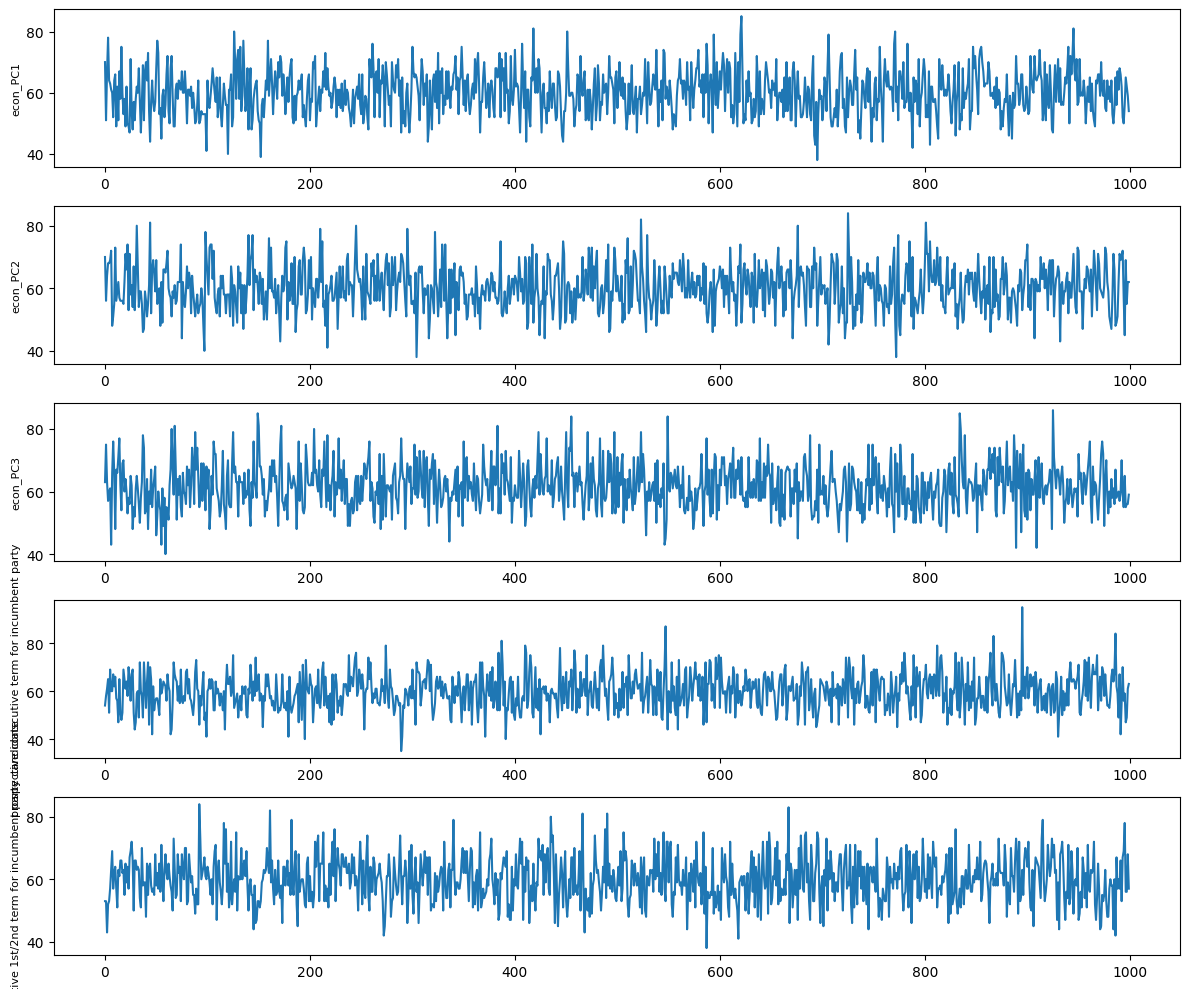

      actual  bart_PC3_econ  bart_PC3_econ_lower  bart_PC3_econ_upper
year                                                                 
2016   48.20      49.531454            49.283600            49.716487
2020   46.86      44.059455            43.466832            44.302203
2024   48.34      47.219099            46.933168            47.526987
MSE: 3.6240815587858726


In [ ]:
#bart economic
cols = ['econ_PC1', 'econ_PC2', 'econ_PC3',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_PC3_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp, distribution_df_temp = bart_pred(cols, name)
uncertain_pred_df = pd.merge(uncertain_pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])
distribution_df = pd.concat([distribution_df, distribution_df_temp])

-4.244736651501289
{'fit_time': array([90.5684557 , 80.44981647, 84.58745027, 81.25546455, 83.97234559,
       82.8069098 , 84.16214967, 84.2063961 ]), 'score_time': array([0.62580848, 0.61986542, 0.74268985, 0.62192464, 0.64069486,
       0.75800729, 0.65120816, 0.64835906]), 'test_score': array([ -0.91484433,  -5.20887591, -12.57733464,  -0.04939464,
       -10.35758724,  -0.15124987,  -2.19297751,  -2.50562908])}


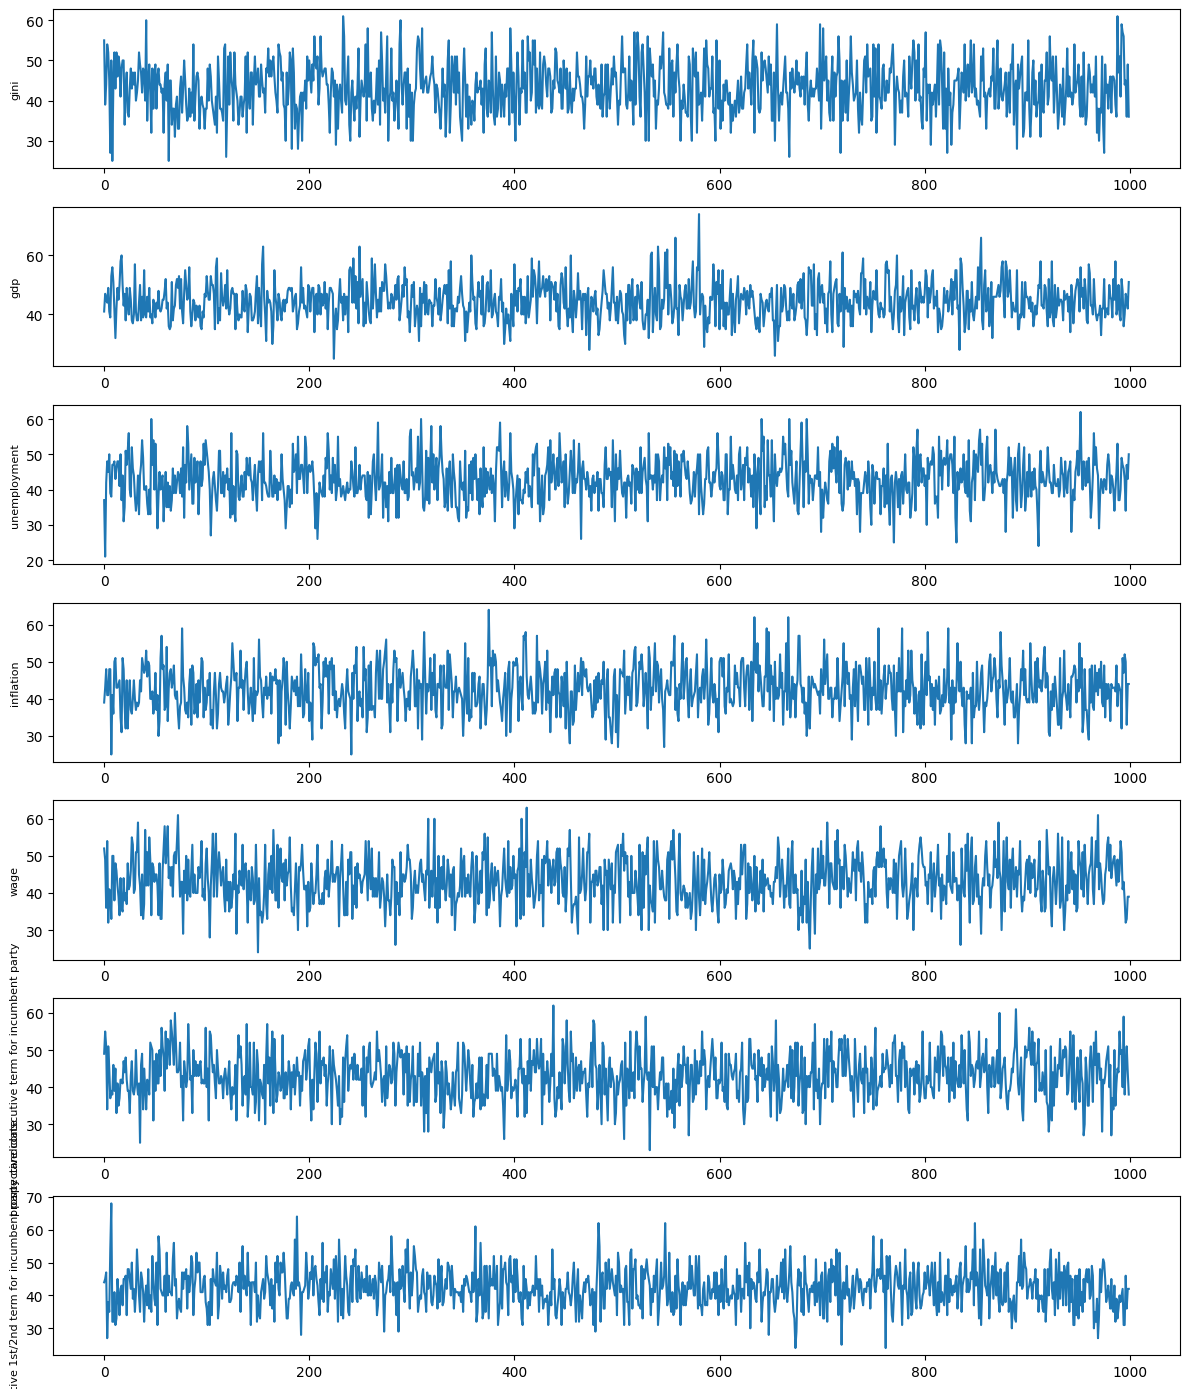

      actual  bart_raw_econ  bart_raw_econ_lower  bart_raw_econ_upper
year                                                                 
2016   48.20      48.368532            48.191396            49.102576
2020   46.86      48.696332            48.373317            49.844238
2024   48.34      50.205194            49.955506            51.112173
MSE: 2.293154762381955


In [47]:
#bart economic
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_raw_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp, distribution_df_temp = bart_pred(cols, name)
uncertain_pred_df = pd.merge(uncertain_pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])
distribution_df = pd.concat([distribution_df, distribution_df_temp])

-7.024758720170107
{'fit_time': array([76.77429605, 77.22682047, 78.94532776, 77.48025131, 78.95651913,
       77.74989295, 81.43309522, 83.64139605]), 'score_time': array([0.63360119, 0.62987399, 0.66001701, 0.6143043 , 0.64924908,
       0.63683987, 0.72265983, 0.59553885]), 'test_score': array([ -3.72739604, -11.7846886 ,  -2.85889306,  -2.19798284,
       -26.53654017,  -3.26633822,  -4.97181532,  -0.85441551])}


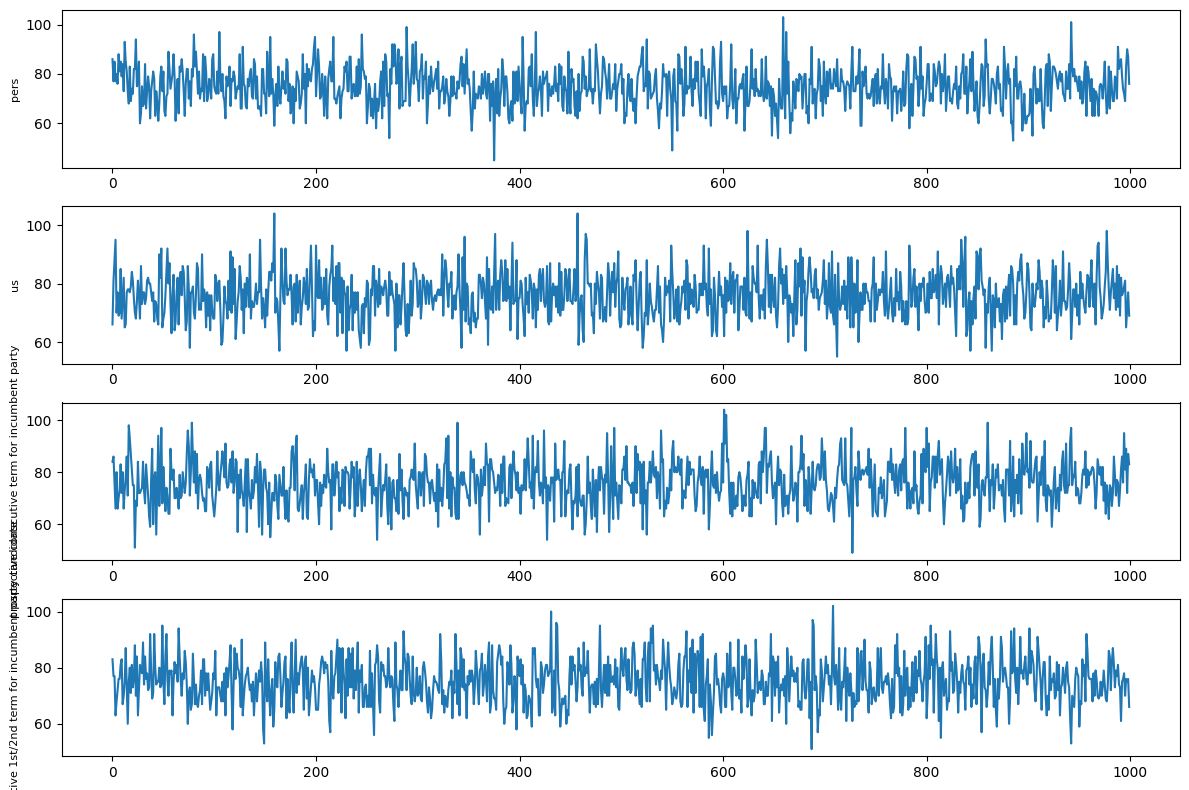

      actual  bart_well_us  bart_well_us_lower  bart_well_us_upper
year                                                              
2016   48.20     45.692158           45.520254           46.042006
2020   46.86     48.342557           48.060717           48.570684
2024   48.34     47.473891           47.344029           47.690927
MSE: 3.0791316819361767


In [48]:
#bart well-being
cols = ['pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_well_us'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp, distribution_df_temp = bart_pred(cols, name)
uncertain_pred_df = pd.merge(uncertain_pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])
distribution_df = pd.concat([distribution_df, distribution_df_temp])

-4.003180617069761
{'fit_time': array([75.33294845, 74.94813538, 75.96170998, 75.1804986 , 92.90606189,
       76.16195202, 77.40741968, 76.77585149]), 'score_time': array([0.63301945, 0.61560822, 0.60706353, 0.61706018, 0.60829639,
       0.62283087, 0.61417603, 0.60967255]), 'test_score': array([ -0.60456021,  -1.38542629,  -0.70386298,  -5.88438802,
        -3.29165133,  -0.08048362, -20.03764114,  -0.03743134])}


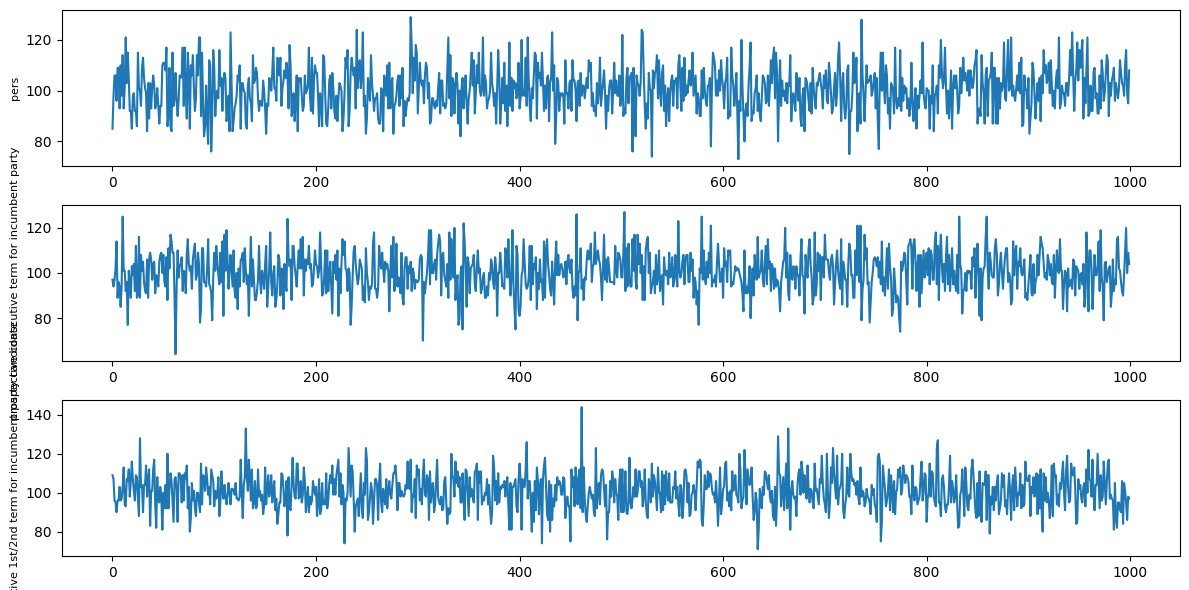

      actual  bart_well  bart_well_lower  bart_well_upper
year                                                     
2016   48.20  46.927771        46.545230        47.094866
2020   46.86  50.672999        50.550609        51.021110
2024   48.34  49.033726        48.877320        49.559095
MSE: 5.546260170038203


In [49]:
#bart well-being
cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_well'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp, distribution_df_temp = bart_pred(cols, name)
uncertain_pred_df = pd.merge(uncertain_pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])
distribution_df = pd.concat([distribution_df, distribution_df_temp])

## exporting and checking

In [ ]:
bart_df.to_csv('bart_df.csv', encoding='utf-8', index=False)
var_df.to_csv('var_df.csv', encoding='utf-8', index=False)
uncertain_pred_df.to_csv('pred_df.csv', encoding='utf-8', index=True)

In [51]:
distribution_df.to_csv('distribution_df.csv', encoding='utf-8', index=False)

In [52]:
#!pip install pandas

In [54]:
pd.read_csv('bart_df.csv')

,method,MSE
0,bart_all,5.536038
1,bart_PC2_econ,7.973050
2,bart_PC3_econ,4.140851
3,bart_raw_econ,4.244737
4,bart_well_us,7.024759
5,bart_well,4.003181


In [55]:
pd.read_csv('var_df.csv')

,predictor,bart_all_inclusion,bart_PC2_econ_inclusion,bart_PC3_econ_inclusion,bart_raw_econ_inclusion,bart_well_us_inclusion,bart_well_inclusion
0,econ_PC1,NaN,75.531,60.082,NaN,NaN,NaN
1,econ_PC2,NaN,76.541,60.179,NaN,NaN,NaN
2,econ_PC3,NaN,NaN,61.675,NaN,NaN,NaN
3,gini,33.498,NaN,NaN,43.181,NaN,NaN
4,gdp,34.119,NaN,NaN,44.562,NaN,NaN
5,unemployment,33.541,NaN,NaN,42.931,NaN,NaN
6,inflation,33.155,NaN,NaN,42.754,NaN,NaN
7,wage,33.428,NaN,NaN,43.467,NaN,NaN
8,pers,33.482,NaN,NaN,NaN,74.948,100.680
9,us,33.775,NaN,NaN,NaN,76.129,NaN


In [56]:
pd.read_csv('pred_df.csv')

,year,actual,bart_all,bart_all_lower,bart_all_upper,bart_PC2_econ,bart_PC2_econ_lower,bart_PC2_econ_upper,bart_PC3_econ,bart_PC3_econ_lower,bart_PC3_econ_upper,bart_raw_econ,bart_raw_econ_lower,bart_raw_econ_upper,bart_well_us,bart_well_us_lower,bart_well_us_upper,bart_well,bart_well_lower,bart_well_upper
0,2016,48.20,47.406033,46.911056,47.587911,47.230462,47.087446,47.585254,49.531454,49.283600,49.716487,48.368532,48.191396,49.102576,45.692158,45.520254,46.042006,46.927771,46.545230,47.094866
1,2020,46.86,48.042928,47.316690,48.256045,47.787625,47.380574,47.969653,44.059455,43.466832,44.302203,48.696332,48.373317,49.844238,48.342557,48.060717,48.570684,50.672999,50.550609,51.021110
2,2024,48.34,48.305381,47.740520,48.517232,51.760233,51.544561,52.425460,47.219099,46.933168,47.526987,50.205194,49.955506,51.112173,47.473891,47.344029,47.690927,49.033726,48.877320,49.559095
